<div style="font-family: Calibri; background-color: #ccd5ae; padding: 10px 10px;">
    <h2>XGBoost</h2>
    <ul>
        <li>Typical Workflow</li>
        <ul>
            <li>Data Preprocessing</li>
            <ul>
                <li>OneHotEncoding and scale features</li>
            </ul>
        </ul>
        <ul>
            <li>SMOTETomek</li>
            <ul>
                <li>Apply SMOTETomek to the training data to balance the class distribution.</li>
            </ul>
        </ul>
        <ul>
            <li>PCA</li>
            <ul>
                <li>Apply PCA to the resampled training data to reduce dimensionality.</li>
            </ul>
        </ul>
        <ul>
            <li>XGBoost</li>
            <ul>
                <li>Train an XGBoost classifier on the transformed training data.</li>
            </ul>
        </ul>
        <ul>
            <li>Evaluation</li>
            <ul>
                <li>Evaluate the model's performance on the test data.</li>
            </ul>
        </ul>
    </ul>  
</div>

In [1]:
import pandas as pd
import numpy as np
import warnings
from sklearn import set_config
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from scripts.plot_tetha import plot_model
import seaborn as sns
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, make_scorer, confusion_matrix, fbeta_score
from sklearn.pipeline import Pipeline

In [2]:
%load_ext autoreload
%autoreload 2
from scripts.scores import calc_predict_proba, calc_scores, confusion_matrix_display
from scripts.decision_tree import determine_parameter

In [3]:
warnings.filterwarnings("ignore") 
set_config(display='diagram')
pd.options.display.precision=3
pd.set_option('display.float_format', lambda x: '%.3f' % x)

<div style="font-family: Calibri; background-color: #faedcd; padding: 5px;">
    <h2>1. Loading Train and Test dataset</h2>
</div>

In [4]:
df = pd.read_csv("data/train.csv" )
df.shape

(255347, 18)

In [5]:
X = df.drop(columns=['Default', 'LoanID', 'DTIRatio', 'CreditScore'])
y = df['Default']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print(X_train.shape, X_test.shape,  y_train.shape, y_test.shape)

(204277, 14) (51070, 14) (204277,) (51070,)


<hr>
<div style="font-family: Calibri; background-color: #faedcd; padding: 5px 5px 5px 5px;">
    <h2>2. Column Transformation</h2>
</div>

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures

<div style="font-family: Calibri; font-size: 18px; background-color: #fefae0; padding: 3px 3px 3px 10px;">
    <h3>Univariate Analysis - Conclusion (Recap)</h3>    
    <ul>
            <li>HasCoSigner, HasDependents, HasMortgage are binary fields</li>
            <li>Education, EmploymentType, LoanPurpose, MaritalStatus are categorical data</li>
    </ul>        
    <h4>Transformation is done external to pipeline to avoid the redundent step In GridSearchCV
    </h4>
</div>

In [8]:
numerical_features = X_train.select_dtypes(exclude='object').columns.tolist()
categorial_features = X_train.select_dtypes(include='object').columns.tolist()

In [9]:
transformer = ColumnTransformer(
    [
        ('Binary', OneHotEncoder(drop='if_binary'), ['HasCoSigner', 'HasDependents', 'HasMortgage']),
        ('multi_category', OneHotEncoder(),  ['Education', 'EmploymentType', 'MaritalStatus']),
        ('Loan_category', OneHotEncoder(categories = [['Business', 'Home']], handle_unknown='ignore'), ['LoanPurpose']), 
    ], remainder=Pipeline([
            ('poly', PolynomialFeatures(degree=2, include_bias=True)),
            ('scaler', MinMaxScaler())
        ])
)

In [10]:
X_train = transformer.fit_transform(X_train)

In [11]:
X_test = transformer.transform(X_test)

<hr>
<div style="font-family: Calibri; background-color: #faedcd; padding: 5px 5px 5px 5px;">
    <h2>3. SMOTE+Tomek</h2>
</div>

In [12]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from imblearn.combine import SMOTETomek

In [13]:
# Initialize the SMOTE
rus = SMOTETomek(random_state=42)

# Fit and apply the undersampling
X_resampled, y_resampled = rus.fit_resample(X_train, y_train)

In [14]:
# The resampled data is now balanced
print("Shape of X before undersampling:", X_train.shape)
print("Shape of X after undersampling:", X_resampled.shape)
print("Value counts before undersampling:", pd.Series(y_train).value_counts())
print("Value counts after undersampling:", pd.Series(y_resampled).value_counts())

Shape of X before undersampling: (204277, 52)
Shape of X after undersampling: (360328, 52)
Value counts before undersampling: Default
0    180524
1     23753
Name: count, dtype: int64
Value counts after undersampling: Default
0    180164
1    180164
Name: count, dtype: int64


In [15]:
X_train, y_train = X_resampled, y_resampled

<hr>
<div style="font-family: Calibri; background-color: #faedcd; padding: 5px 5px 5px 5px;">
    <h2>4. PCA</h2>
</div>

In [16]:
from sklearn.decomposition import PCA

In [17]:
pca = PCA()

In [18]:
X_pca = pca.fit_transform(X_train)

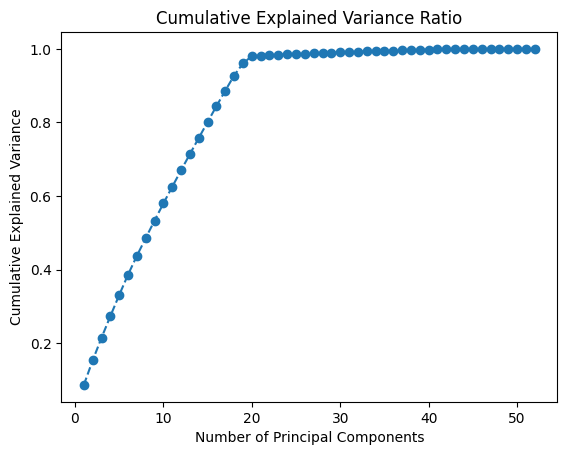

In [19]:
# Plot explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

plt.plot(range(1, len(explained_variance_ratio) + 1), cumulative_explained_variance, marker='o' , linestyle='--')
plt.title('Cumulative Explained Variance Ratio') 
plt.xlabel('Number of Principal Components') 
plt.ylabel('Cumulative Explained Variance')
plt.show()

In [20]:
n_components = np.argmax(cumulative_explained_variance >= 0.95) + 1
print(f"Number of components to retain 95% variance: {n_components}")

Number of components to retain 95% variance: 19


<hr>
<div style="font-family: Calibri; background-color: #faedcd; padding: 5px 5px 5px 5px;">
    <h2>4. PCA + XGBClassifier</h2>
</div>

In [21]:
import xgboost as xgb

In [22]:
pipeline = Pipeline([
    ('pca', PCA(n_components=n_components)),  # Reduce dimensions using PCA
    ('model', xgb.XGBClassifier(objective='binary:logistic', 
                               eval_metric=make_scorer(fbeta_score, beta=2, pos_label=1),
                               enable_categorical=True,                          
                               random_state=42))  # Train Logistic Regression model
])

In [23]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('pca', PCA(n_components=19)),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=True,
                               eval_metric=make_scorer(fbeta_score, response_method='predict', beta=2, pos_label=1),
                               feature_types=None, gamma=N...ow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, random_state=42, ...))])

In [33]:
rs = recall_score(y_test, y_pred, pos_label=1)
ps = precision_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)
ac = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_pred)
print(f"{'Recall Score:':<20}{rs:.3}")
print(f"{'Precision Score:':<20}{ps:.3}")
print(f"{'F1 Score:':<20}{f1:.3}")
print(f"{'ROC AUC Score:':<20}{roc:.3}")
print(f"{'Accuracy Score:':<20}{ac:.3}")

Recall Score:       0.522
Precision Score:    0.241
F1 Score:           0.33
ROC AUC Score:      0.654
Accuracy Score:     0.755


In [25]:
y_pred = pipeline.predict(X_test)

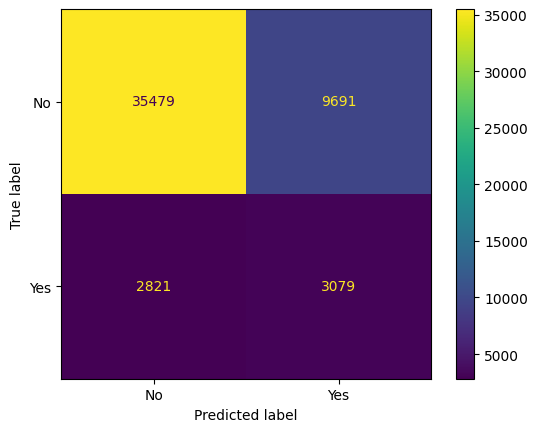

In [26]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, values_format='d', display_labels=["No","Yes"]);

In [27]:
y_train_pred_prob, y_test_pred_prob = calc_predict_proba(pipeline, X_train, y_train, X_test, y_test)

In [28]:
rs_list, ps_list, f1_list, ac_list = [],[],[],[]
for thresh in np.arange(0.3,0.8,0.1):
    rs, ps, f1, ac, y_test_pred = calc_scores(pipeline, X_train, y_train, y_train_pred_prob, X_test, y_test, y_test_pred_prob, thresh)
    rs_list.append(rs) 
    ps_list.append(ps)
    f1_list.append(f1)
    ac_list.append(ac)

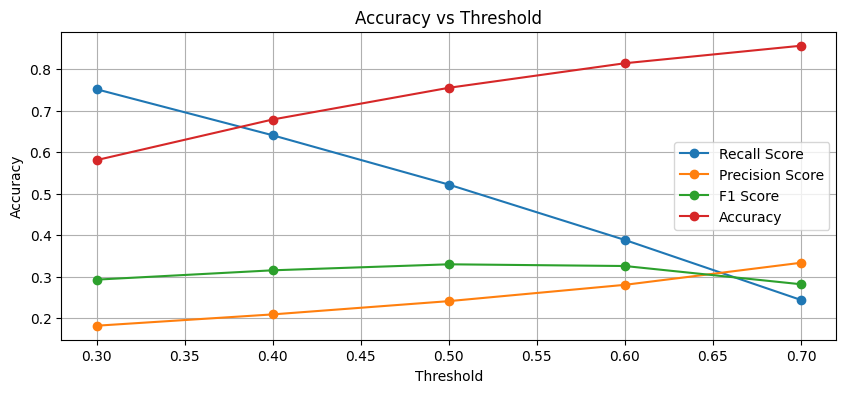

In [29]:
plt.figure(figsize=(10, 4))

plt.plot(np.arange(0.3,0.8,0.1), rs_list, label='Recall Score', marker='o')
plt.plot(np.arange(0.3,0.8,0.1), ps_list, label='Precision Score', marker='o')
plt.plot(np.arange(0.3,0.8,0.1), f1_list, label='F1 Score', marker='o')
plt.plot(np.arange(0.3,0.8,0.1), ac_list, label='Accuracy', marker='o')
plt.xlabel('Threshold')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Threshold')
plt.legend()
plt.grid(True)
plt.savefig("images/PCA_XGBClassifier.png")
plt.show()

In [30]:
pd.DataFrame({"recall": rs_list, "precision": ps_list, "f1-score": f1_list, "accuracy":ac_list}, index = np.arange(0.3,0.8,0.1))

,recall,precision,f1-score,accuracy
0.300,0.752,0.182,0.293,0.581
0.400,0.641,0.209,0.315,0.679
0.500,0.522,0.241,0.330,0.755
0.600,0.388,0.280,0.326,0.814
0.700,0.244,0.334,0.282,0.856


<hr>
<div style="font-family: Calibri; background-color: #faedcd; padding: 5px 5px 5px 5px;">
    <h2>5. XGBClassifier</h2>
</div>

In [35]:
pipeline = Pipeline([
    ('model', xgb.XGBClassifier(objective='binary:logistic', 
                               eval_metric=make_scorer(fbeta_score, beta=2, pos_label=1),
                               enable_categorical=True,                          
                               random_state=42))  # Train Logistic Regression model
])

In [36]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=True,
                               eval_metric=make_scorer(fbeta_score, response_method='predict', beta=2, pos_label=1),
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, random_state=42, ...))])

In [43]:
y_pred = pipeline.predict(X_test)

In [44]:
rs = recall_score(y_test, y_pred, pos_label=1)
ps = precision_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)
ac = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_pred)
print(f"{'Recall Score:':<20}{rs:.3}")
print(f"{'Precision Score:':<20}{ps:.3}")
print(f"{'F1 Score:':<20}{f1:.3}")
print(f"{'ROC AUC Score:':<20}{roc:.3}")
print(f"{'Accuracy Score:':<20}{ac:.3}")

Recall Score:       0.0929
Precision Score:    0.509
F1 Score:           0.157
ROC AUC Score:      0.541
Accuracy Score:     0.885


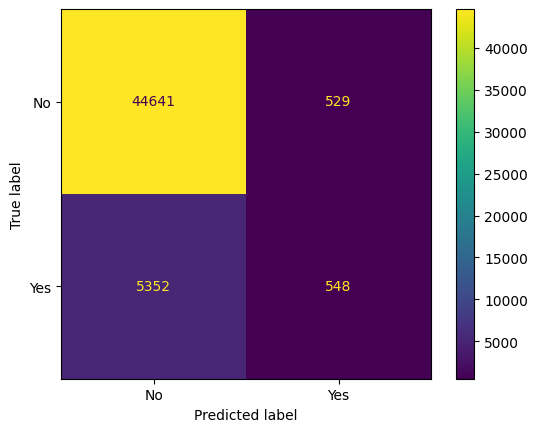

In [45]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, values_format='d', display_labels=["No","Yes"]);

In [46]:
y_train_pred_prob, y_test_pred_prob = calc_predict_proba(pipeline, X_train, y_train, X_test, y_test)

In [47]:
rs_list, ps_list, f1_list, ac_list = [],[],[],[]
for thresh in np.arange(0.3,0.8,0.1):
    rs, ps, f1, ac, y_test_pred = calc_scores(pipeline, X_train, y_train, y_train_pred_prob, X_test, y_test, y_test_pred_prob, thresh)
    rs_list.append(rs) 
    ps_list.append(ps)
    f1_list.append(f1)
    ac_list.append(ac)

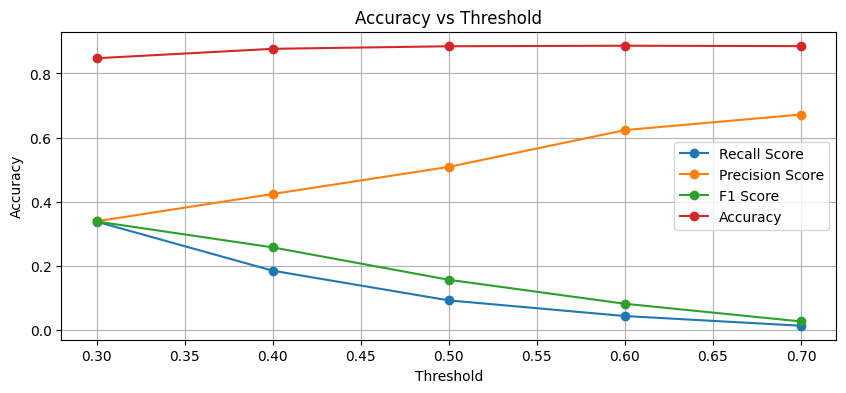

In [48]:
plt.figure(figsize=(10, 4))

plt.plot(np.arange(0.3,0.8,0.1), rs_list, label='Recall Score', marker='o')
plt.plot(np.arange(0.3,0.8,0.1), ps_list, label='Precision Score', marker='o')
plt.plot(np.arange(0.3,0.8,0.1), f1_list, label='F1 Score', marker='o')
plt.plot(np.arange(0.3,0.8,0.1), ac_list, label='Accuracy', marker='o')
plt.xlabel('Threshold')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Threshold')
plt.legend()
plt.grid(True)
plt.savefig("images/XGBClassifier-II.png")
plt.show()

In [49]:
pd.DataFrame({"recall": rs_list, "precision": ps_list, "f1-score": f1_list, "accuracy":ac_list}, index = np.arange(0.3,0.8,0.1))

,recall,precision,f1-score,accuracy
0.300,0.338,0.339,0.339,0.847
0.400,0.185,0.424,0.258,0.877
0.500,0.093,0.509,0.157,0.885
0.600,0.044,0.624,0.082,0.886
0.700,0.014,0.672,0.027,0.885
